# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [1]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [2]:









from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [3]:
# The original KDD dataset (10% version) will be used without further sampling to avoid removing classes.
# If performance is an issue, consider alternative stratified sampling or reducing the original dataset size.
# df = df.sample(n=5000, random_state=42) # Removed this line

print(df.shape)

(494021, 42)


## Data Preprocessing & Feature Engineering

In [4]:

# Encoding categorical variables into numeric form
categorical_encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = categorical_encoder.fit_transform(df[col])

# Convert labels into binary classification (attack or normal)
# Handle byte strings properly by decoding or comparing with bytes
df['label'] = df['label'].apply(lambda x: 'normal' if (x == b'normal.' or x == 'normal.') else 'attack')
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

print("Label distribution after preprocessing:")
print(df['label'].value_counts())
print(f"\nClasses: {label_encoder.classes_}")
df.head()


Label distribution after preprocessing:
label
0    396743
1     97278
Name: count, dtype: int64

Classes: ['attack' 'normal']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
0,0,1,22,9,181,5450,0,0,0,0,...,0.11,0.0,0.0,0.0,0.0,0.0,1,0.033205,16,0.0
1,0,1,22,9,239,486,0,0,0,0,...,0.05,0.0,0.0,0.0,0.0,0.0,1,0.49076,16,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,1,0.175635,16,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,1,0.163677,12,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,0.02,0.0,0.0,0.0,0.0,0.0,1,0.106739,12,0.0


## Splitting Data into Training and Testing Sets

In [5]:
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [6]:
# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier - Commented out due to single class issue
# gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
# gb.fit(X_train, y_train)
# y_pred_gb = gb.predict(X_test)
# print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
# print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM) - Commented out due to single class issue
# svm = SVC(kernel='linear', probability=True)
# svm.fit(X_train, y_train)
# y_pred_svm = svm.predict(X_test)
# print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
# print(classification_report(y_test, y_pred_svm))

Random Forest Accuracy: 0.9998380648752594
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79349
           1       1.00      1.00      1.00     19456

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



In [7]:
print('Value counts for the label column:')
print(df['label'].value_counts())

Value counts for the label column:
label
0    396743
1     97278
Name: count, dtype: int64


## Building a Neural Network Classifier

In [8]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 50s 4ms/step - accuracy: 0.9953 - loss: 0.0217 - val_accuracy: 0.9985 - val_loss: 0.0070
Epoch 2/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9983 - loss: 0.0090 - val_accuracy: 0.9989 - val_loss: 0.0058
Epoch 3/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9986 - loss: 0.0064 - val_accuracy: 0.9990 - val_loss: 0.0110
Epoch 4/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - accuracy: 0.9986 - loss: 0.0066 - val_accuracy: 0.9989 - val_loss: 0.0091
Epoch 5/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9987 - loss: 0.0076 - val_accuracy: 0.9990 - val_loss: 0.0071
Epoch 6/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9988 - loss: 0.0063 - val_accuracy: 0.9991 - val_loss: 0.0087
Epoch 7/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9988 - loss: 0.0058 - val_accuracy: 0.9989 - val_loss: 0.0092
Epoch 8/20
12351/12351 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 

## Evaluating Neural Network Performance

3088/3088 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Neural Network Accuracy: 0.9991802034310004
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79349
           1       1.00      1.00      1.00     19456

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



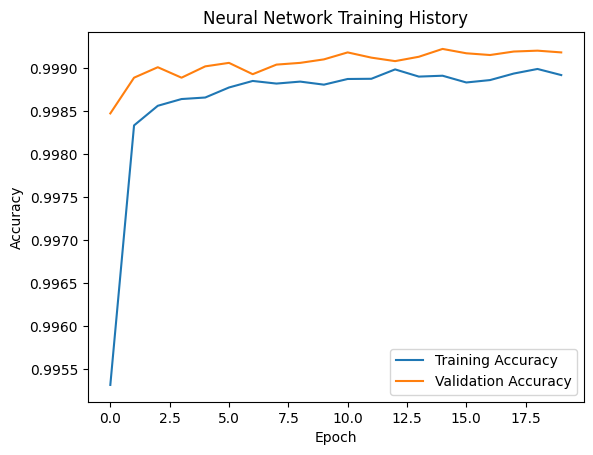

In [9]:

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models

